In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/sudan.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [3]:
import numpy as np 
df.replace(-999, np.nan, inplace=True)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [4]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,2015-01-05,1


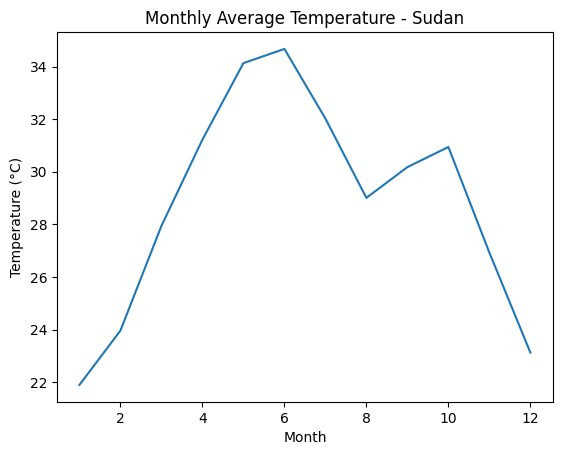

In [5]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature - Sudan")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### 🌡️ Monthly Temperature Pattern - Sudan
- **Warm rise**: Temperatures climb from ~22°C in January to ~35°C by May–June.  
- **Gradual decline**: Cooling trend toward year-end, settling near ~23°C.  
- **Key feature**: Strong seasonal cycle with a pronounced mid-year heat peak.  

**Takeaway**: Sudan experiences **intense summer heat**, followed by a steady cooling phase.


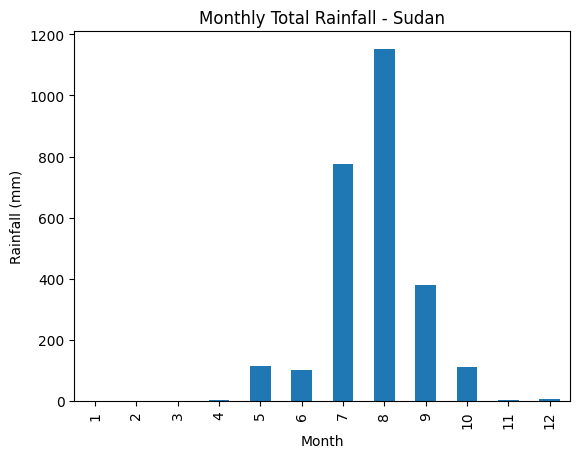

In [6]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall - Sudan")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### 🌧️ Monthly Rainfall Pattern - Sudan
- **Peak rainfall**: August (~1150 mm), with July (~780 mm) as the strong lead-in.  
- **Secondary taper**: September (~380 mm) continues the wet season before decline.  
- **Dry months**: January–March show almost no rainfall.  

**Key takeaway**: Sudan’s rainfall is **highly seasonal**, concentrated mid-year, with long dry spells dominating the rest.


In [7]:
extreme_days = df[df["T2M_MAX"] > 35]
len(extreme_days)


2694

### 🔥 Extreme Heat Days - Sudan
- **Observation**: 2,694 days exceeded 35°C threshold.  
- **Implication**: Frequent extreme heat events dominate the climate profile.  
- **Risk factor**: Highlights vulnerability to prolonged hot conditions.  

**Key takeaway**: Sudan’s climate is **heat-intensive**, with extreme temperatures shaping environmental and human challenges.


In [8]:
df.to_csv("../data/sudan_clean.csv", index=False)